In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text, plot_tree

In [2]:
df = pd.read_excel("df_po_oczyszczeniu.xlsx")
df_dd = df.drop(columns=['ReturningVisitor', 'OtherVisitor', 'BounceRates', 'Region1', 'Month_5', 'OperatingSystem2', 'Browser2', 'PageValues'])
df_dd

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,SpecialDay,Month_2,Month_3,...,Region5,Region6,Region7,Region8,Region9,NewVisitor,IfWeekend,Y_IfRevenue,OperatingSystemOther,BrowserOther
0,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.100000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.140000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.050000,0.0,1,0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.029031,0.0,0,0,...,0,0,0,0,0,0,1,0,1,1
12326,0,0.0,0,0.0,5,465.750000,0.021333,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12327,0,0.0,0,0.0,6,184.250000,0.086667,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12328,4,75.0,0,0.0,15,346.000000,0.021053,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_dd.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'ExitRates', 'SpecialDay', 'Month_2', 'Month_3', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'OperatingSystem1', 'OperatingSystem3', 'Browser1', 'Region2',
       'Region3', 'Region4', 'Region5', 'Region6', 'Region7', 'Region8',
       'Region9', 'NewVisitor', 'IfWeekend', 'Y_IfRevenue',
       'OperatingSystemOther', 'BrowserOther'],
      dtype='object')

In [3]:
X = df_dd.drop('Y_IfRevenue', axis=1)
Y = df_dd['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)

# Trenowanie modelu

In [5]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=1
)
dt.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
Y_val_pred = dt.predict(X_val)

#Macierz pomyłek
print(confusion_matrix(Y_val, Y_val_pred))

#raport klasyfikacji
print(classification_report(Y_val, Y_val_pred))

[[1872  317]
 [ 292  109]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2189
           1       0.26      0.27      0.26       401

    accuracy                           0.76      2590
   macro avg       0.56      0.56      0.56      2590
weighted avg       0.77      0.76      0.77      2590



# Zależność max depth a recall na train i val

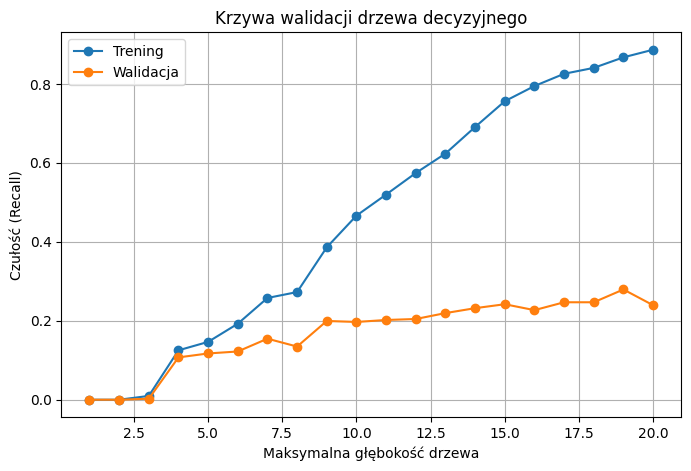

In [7]:
# Lista wartości max_depth do przetestowania
max_depth_values = np.arange(1, 21)  # od 1 do 20

# Listy do przechowywania wyników
train_recalls = []
val_recalls = []

# Pętla po różnych głębokościach drzewa
for depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, Y_train)
    
     # Recall na zbiorze treningowym
    train_recall = recall_score(Y_train, dt.predict(X_train))
    train_recalls.append(train_recall)
    
    # Recall na zbiorze walidacyjnym
    val_recall = recall_score(Y_val, dt.predict(X_val))
    val_recalls.append(val_recall)


# Wizualizacja
plt.figure(figsize=(8,5))
plt.plot(max_depth_values, train_recalls, label='Trening', marker='o')
plt.plot(max_depth_values, val_recalls, label='Walidacja', marker='o')
plt.xlabel('Maksymalna głębokość drzewa')
plt.ylabel('Czułość (Recall)')
plt.title('Krzywa walidacji drzewa decyzyjnego')
plt.legend()
plt.grid(True)
plt.show()

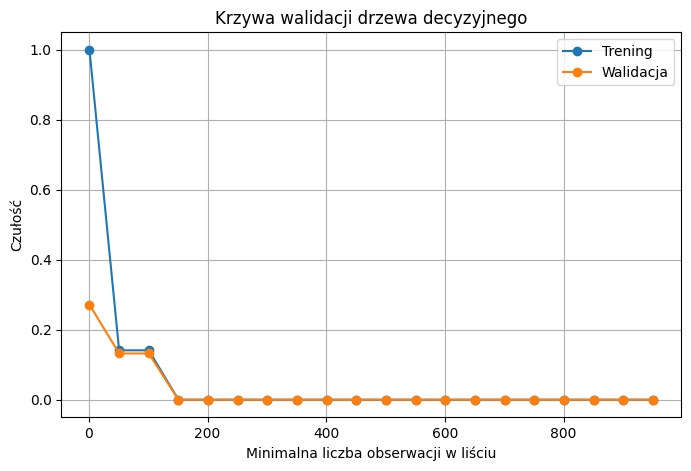

In [8]:
# Lista wartości min_samples_leaf do przetestowania
min_samples_leaf_values = np.arange(1, 1000, 50)  # od 1 do 20

# Listy do przechowywania wyników
train_recalls = []
val_recalls = []

# Pętla po różnych wartościach min_samples_leaf
for leaf_size in min_samples_leaf_values:
    dt = DecisionTreeClassifier(
        min_samples_leaf=leaf_size,
        random_state=42
    )
    dt.fit(X_train, Y_train)
    
    # Czułość na zbiorze treningowym
    train_recall = recall_score(Y_train, dt.predict(X_train))
    train_recalls.append(train_recall)
    
    # Czułość na zbiorze walidacyjnym
    val_recall = recall_score(Y_val, dt.predict(X_val))
    val_recalls.append(val_recall)

# Wizualizacja
plt.figure(figsize=(8,5))
plt.plot(min_samples_leaf_values, train_recalls, label='Trening', marker='o')
plt.plot(min_samples_leaf_values, val_recalls, label='Walidacja', marker='o')
plt.xlabel('Minimalna liczba obserwacji w liściu')
plt.ylabel('Czułość')
plt.title('Krzywa walidacji drzewa decyzyjnego')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.tree import plot_tree

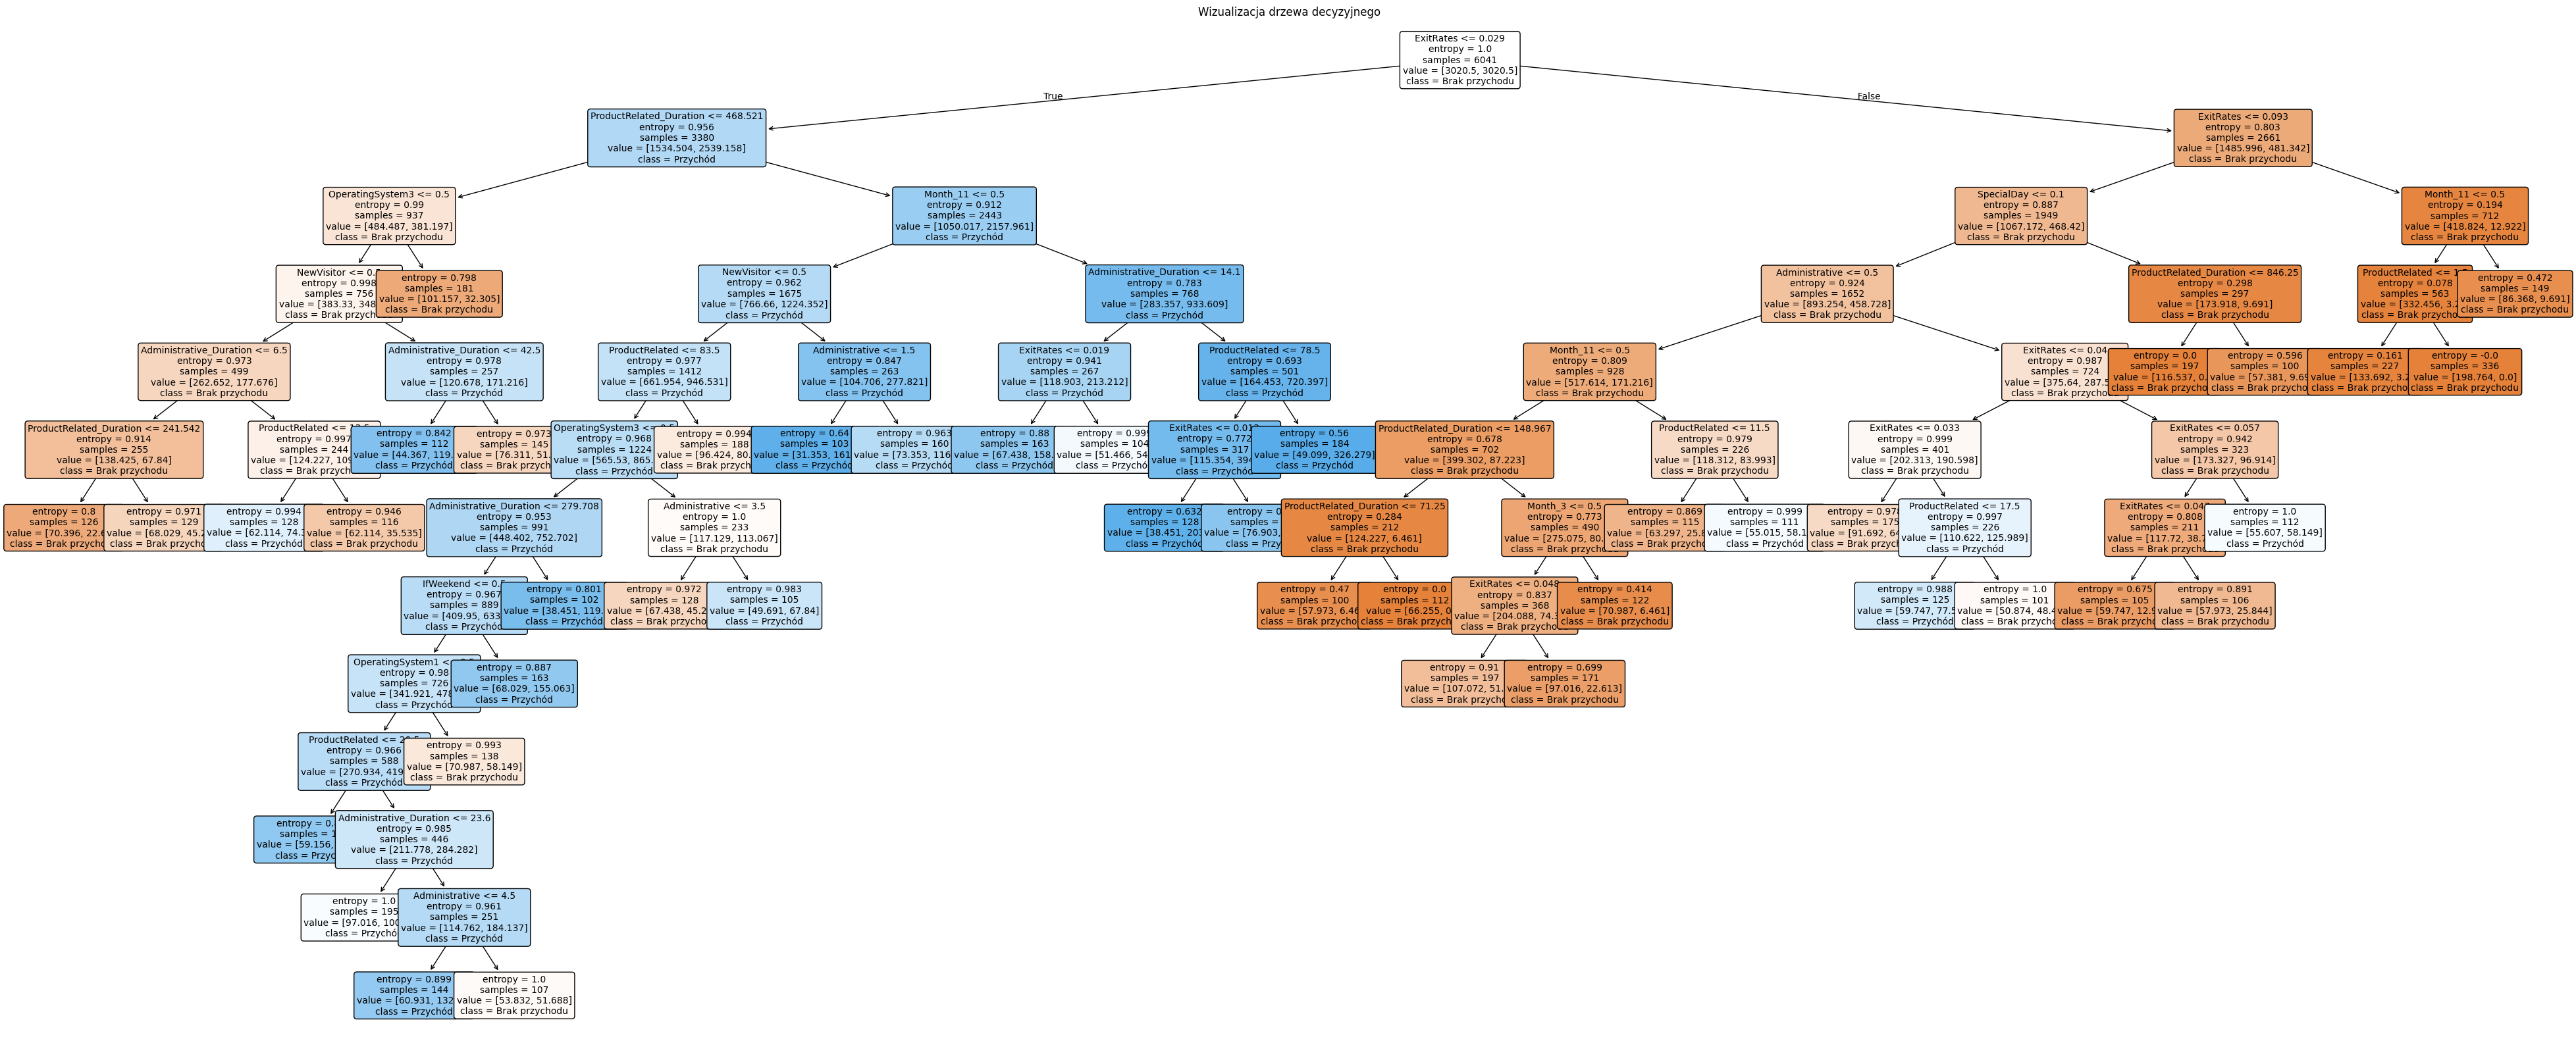

In [24]:
#drzewo decyzyjne dla min leaf samples 100 i wizualizacja

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=100,
    class_weight='balanced',
    criterion='entropy'
)
dt.fit(X_train, Y_train)

plt.figure(figsize=(50, 20))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['Brak przychodu', 'Przychód'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Wizualizacja drzewa decyzyjnego')
plt.show()

In [26]:
#raport klasyfikacji i macierz pomyłek

Y_val_pred = dt.predict(X_val)

print(confusion_matrix(Y_val, Y_val_pred))

print(classification_report(Y_val, Y_val_pred))

[[1446  743]
 [ 118  283]]
              precision    recall  f1-score   support

           0       0.92      0.66      0.77      2189
           1       0.28      0.71      0.40       401

    accuracy                           0.67      2590
   macro avg       0.60      0.68      0.58      2590
weighted avg       0.82      0.67      0.71      2590



# Sprawdzam różne strategie aby max recall

Najlepszy próg (F1): 0.590
Recall: 0.559
Precision: 0.348
F1-score: 0.429

Najlepszy próg dla recall >= 0.75:
Threshold: 0.427
Recall: 0.800
Precision: 0.249


C:\Users\sonet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sonet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


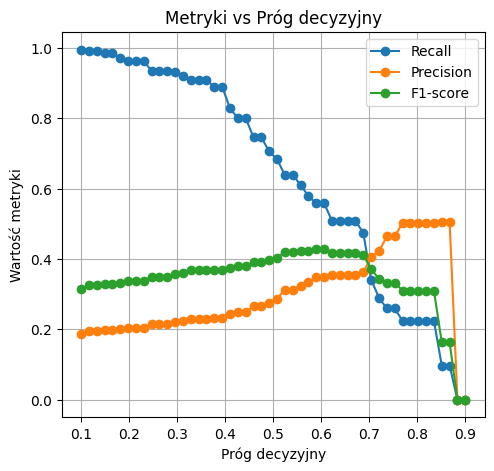

In [15]:
# Strategia 2: Regulacja progu decyzyjnego (threshold tuning)
# Zamiast używać domyślnego progu 0.5, szukamy optymalnego

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=100,
    class_weight='balanced',
    criterion='entropy'
)
dt.fit(X_train, Y_train)

# Pobieramy prawdopodobieństwa przewidywań
y_proba_val = dt.predict_proba(X_val)[:, 1]

# Testujemy różne progi
thresholds = np.linspace(0.1, 0.9, 50)
threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_proba_val >= threshold).astype(int)
    
    recall = recall_score(Y_val, y_val_pred_threshold)
    precision = precision_score(Y_val, y_val_pred_threshold)
    f1 = f1_score(Y_val, y_val_pred_threshold)
    
    threshold_results.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

# Znajdź próg z najlepszym F1 score
best_f1_idx = threshold_df['f1'].idxmax()
best_threshold = threshold_df.loc[best_f1_idx, 'threshold']
print(f"Najlepszy próg (F1): {best_threshold:.3f}")
print(f"Recall: {threshold_df.loc[best_f1_idx, 'recall']:.3f}")
print(f"Precision: {threshold_df.loc[best_f1_idx, 'precision']:.3f}")
print(f"F1-score: {threshold_df.loc[best_f1_idx, 'f1']:.3f}")

# Znajdź próg dla recall > 0.75 z najlepszą precyzją
high_recall_df = threshold_df[threshold_df['recall'] >= 0.75]
if len(high_recall_df) > 0:
    best_precision_idx = high_recall_df['precision'].idxmax()
    print(f"\nNajlepszy próg dla recall >= 0.75:")
    print(f"Threshold: {high_recall_df.loc[best_precision_idx, 'threshold']:.3f}")
    print(f"Recall: {high_recall_df.loc[best_precision_idx, 'recall']:.3f}")
    print(f"Precision: {high_recall_df.loc[best_precision_idx, 'precision']:.3f}")

# Wizualizacja krzywej Precision-Recall
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='o')
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='o')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1-score', marker='o')
plt.xlabel('Próg decyzyjny')
plt.ylabel('Wartość metryki')
plt.title('Metryki vs Próg decyzyjny')
plt.legend()
plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(threshold_df['recall'], threshold_df['precision'], marker='o')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Krzywa Precision-Recall')
# plt.grid(True)

# plt.tight_layout()
plt.show()

# Finalny model - najlepsze parametry dla maksymalizacji Recall

### ⚠️ UWAGA: class_weight vs threshold tuning

**Problem:** Jeśli używasz threshold tuning (np. `y_pred = (y_proba >= 0.45)`), to PRZESŁANIA wpływ `class_weight`!

**Jak to działa:**
- `class_weight` - wpływa na **trening** modelu (jak model się uczy)
- `threshold tuning` - wpływa na **predykcję** (jak model klasyfikuje)

**WYBIERZ JEDNO:**
1. **Opcja A:** Użyj `class_weight` + `predict()` (domyślny próg 0.5)
2. **Opcja B:** Użyj `class_weight='balanced'` + threshold tuning na własny próg

**Poniżej:** Używamy Opcji A - zmiana `class_weight` będzie widoczna w wynikach

FINALNY MODEL - WYNIKI NA ZBIORZE WALIDACYJNYM:
Parametry: class_weight={0: 1, 1: 7}, min_samples_leaf=100

Macierz pomyłek:
[[1173 1016]
 [  79  322]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.94      0.54      0.68      2189
           1       0.24      0.80      0.37       401

    accuracy                           0.58      2590
   macro avg       0.59      0.67      0.53      2590
weighted avg       0.83      0.58      0.63      2590

              precision    recall  f1-score   support

           0       0.94      0.54      0.68      2189
           1       0.24      0.80      0.37       401

    accuracy                           0.58      2590
   macro avg       0.59      0.67      0.53      2590
weighted avg       0.83      0.58      0.63      2590



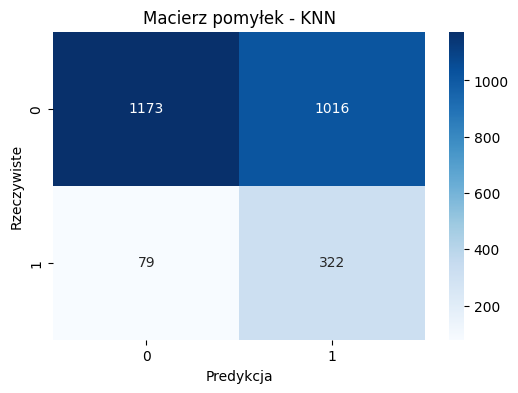

In [52]:
# Model z najlepszymi parametrami (najwyższy recall)
dt = DecisionTreeClassifier(
    class_weight={0: 1, 1: 7},  # Zmień tę wagę aby przetestować różne scenariusze
    criterion='gini',
    max_depth=None,
    min_samples_leaf=100,
    random_state=42
)

dt.fit(X_train, Y_train)

# WAŻNE: Użyj predict() zamiast threshold tuning, aby zobaczyć wpływ class_weight
y_val_pred = dt.predict(X_val)  # Używa domyślnego progu 0.5

print("FINALNY MODEL - WYNIKI NA ZBIORZE WALIDACYJNYM:")
print("=" * 80)
print(f"Parametry: class_weight={dt.class_weight}, min_samples_leaf={dt.min_samples_leaf}")
print("\nMacierz pomyłek:")
cm = confusion_matrix(Y_val, y_val_pred)
print(cm)

print("\nRaport klasyfikacji:")
print(classification_report(Y_val, y_val_pred))

# Macierz pomyłek
cm = confusion_matrix(Y_val, y_val_pred)
cm

print(classification_report(Y_val, y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - KNN")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()



WYNIKI NA ZBIORZE TESTOWYM:

Macierz pomyłek:
[[1660 1467]
 [ 126  446]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.93      0.53      0.68      3127
           1       0.23      0.78      0.36       572

    accuracy                           0.57      3699
   macro avg       0.58      0.66      0.52      3699
weighted avg       0.82      0.57      0.63      3699



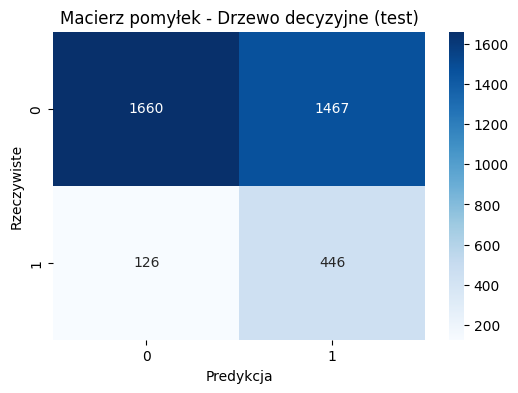

In [53]:
# Predykcja na zbiorze testowym
y_test_pred = dt.predict(X_test)

print("WYNIKI NA ZBIORZE TESTOWYM:")
print("=" * 80)

print("\nMacierz pomyłek:")
cm_test = confusion_matrix(Y_test, y_test_pred)
print(cm_test)

print("\nRaport klasyfikacji:")
print(classification_report(Y_test, y_test_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Drzewo decyzyjne (test)")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

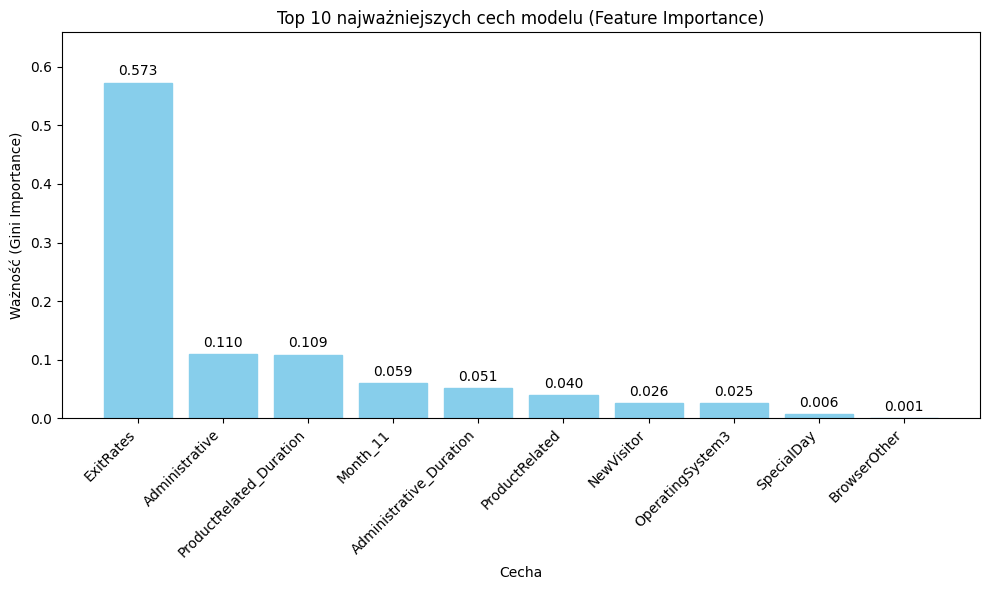

In [61]:
# Ważności cech z drzewa
importances = dt.feature_importances_
feature_names = X_train.columns  # Upewnij się, że używasz X_train lub X, jeśli X_test nie ma nazw kolumn

# DataFrame z ważnościami
feat_imp = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

top10 = feat_imp.head(10)

# Wykres
plt.figure(figsize=(10, 6))
ax = plt.gca() # Pobranie aktualnych osi

# Tworzenie słupków
bars = ax.bar(top10['Cecha'], top10['Ważność'], color='skyblue', edgecolor='skyblue')

# Dodawanie etykiet słupków
ax.bar_label(bars, padding=3, fmt='%.3f') 

# Optymalizacja wyglądu
plt.xticks(rotation=45, ha='right') # Rotacja 45 stopni jest często czytelniejsza niż 90
plt.title("Top 10 najważniejszych cech modelu (Feature Importance)")
plt.ylabel("Ważność (Gini Importance)")
plt.xlabel("Cecha")

# Zwiększenie limitu osi Y, aby etykiety miały miejsce
plt.ylim(0, top10['Ważność'].max() * 1.15)
plt.tight_layout()
plt.show()

In [63]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.1.3 which is incompatible.
matplotlib 3.8.3 requires numpy<2,>=1.21, but you have numpy 2.1.3 which is incompatible.
statsmodels 0.14.1 requires numpy<2,>=1.18, but you have numpy 2.1.3 which is incompatible.
ydata-profiling 4.17.0 requires scipy<1.16,>=1.4.1, but you have scipy 1.17.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\sonet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.8 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 60.8/60.8 kB 1.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ------------- -------------------------- 184.3/548.0 kB 5.4 MB/s eta 0:00:01
   -------------------------- ------------- 368.6/548.0 kB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 548.0/548.0 kB 4.3 MB/s eta 0:00:00
   -----------------

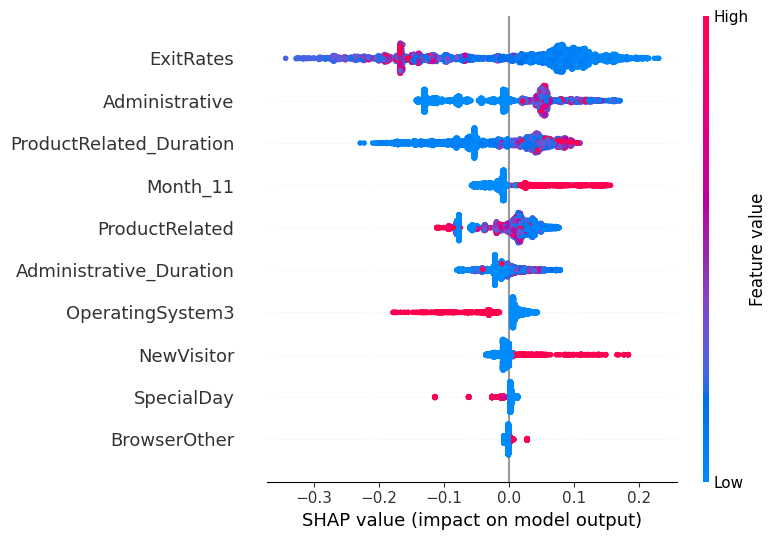

In [66]:
import shap

# Explainer dla drzewa decyzyjnego
explainer = shap.TreeExplainer(dt, X_train)

# Obliczanie wartości SHAP dla zbioru testowego
shap_values = explainer(X_test)  # nowsza wersja SHAP zwraca obiekt Explanation

# Wybór top 10 cech na podstawie feature_importances_
top10_features = feat_imp.head(10)['Cecha'].tolist()
X_test_top10 = X_test[top10_features]

# Wykres SHAP summary dla top 10 cech
shap.summary_plot(
    shap_values.values[:, [X_test.columns.get_loc(f) for f in top10_features], 1], 
    X_test_top10
)

### Analiza kierunku zależności dla najważniejszych cech

Feature importance pokazuje tylko **ważność** cechy, ale nie kierunek wpływu. Poniżej analizujemy kierunek zależności - czy wyższe wartości cechy prowadzą do większej czy mniejszej szansy na przychód.

ANALIZA KIERUNKU ZALEŻNOŚCI - TOP 10 CECH

Interpretacja:
- Pozytywny ↑: Wyższe wartości cechy → większa szansa na przychód
- Negatywny ↓: Wyższe wartości cechy → mniejsza szansa na przychód
- Różnica: Średnia(Przychód) - Średnia(Brak przychodu)

                  Cecha  Średnia (Brak przychodu)  Średnia (Przychód)    Różnica  Korelacja    Kierunek
              ExitRates                  0.046883            0.019564  -0.027319  -0.204996 Negatywny ↓
ProductRelated_Duration               1059.697230         1806.556060 746.858830   0.138895 Pozytywny ↑
Administrative_Duration                 72.129067          114.736345  42.607277   0.090126 Pozytywny ↑
               Month_11                  0.215433            0.400000   0.184567   0.155431 Pozytywny ↑
                Month_3                  0.163533            0.108021  -0.055512  -0.055487 Negatywny ↓
             SpecialDay                  0.070701            0.019679  -0.051022  -0.092208 Negatywny ↓
         Administrative  

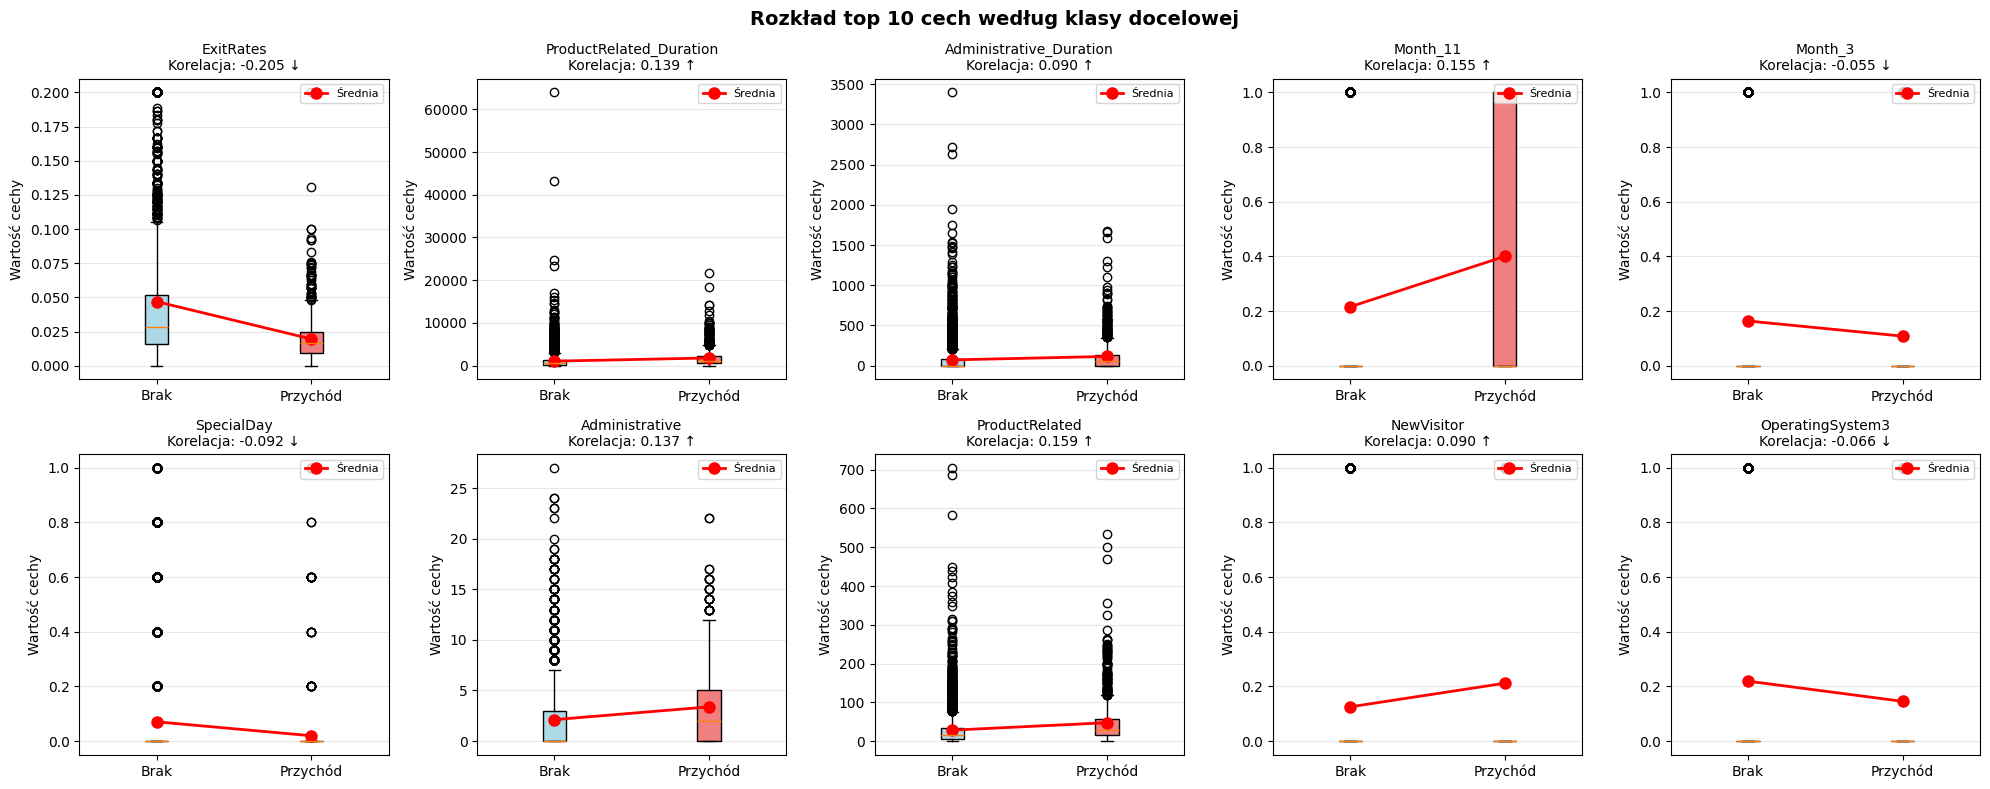

In [18]:
# Analiza kierunku zależności dla top 10 cech
top_features = feature_importance['Feature'].tolist()

# Porównanie średnich wartości dla każdej klasy
direction_analysis = []

for feature in top_features:
    mean_class_0 = X_train[Y_train == 0][feature].mean()
    mean_class_1 = X_train[Y_train == 1][feature].mean()
    
    # Korelacja Pearsona między cechą a zmienną celu
    correlation = X_train[feature].corr(Y_train)
    
    direction_analysis.append({
        'Cecha': feature,
        'Średnia (Brak przychodu)': mean_class_0,
        'Średnia (Przychód)': mean_class_1,
        'Różnica': mean_class_1 - mean_class_0,
        'Korelacja': correlation,
        'Kierunek': 'Pozytywny ↑' if correlation > 0 else 'Negatywny ↓'
    })

direction_df = pd.DataFrame(direction_analysis)

print("ANALIZA KIERUNKU ZALEŻNOŚCI - TOP 10 CECH")
print("=" * 100)
print("\nInterpretacja:")
print("- Pozytywny ↑: Wyższe wartości cechy → większa szansa na przychód")
print("- Negatywny ↓: Wyższe wartości cechy → mniejsza szansa na przychód")
print("- Różnica: Średnia(Przychód) - Średnia(Brak przychodu)")
print("\n" + direction_df.to_string(index=False))

# Wizualizacja kierunku zależności
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Boxplot dla obu klas
    data_to_plot = [
        X_train[Y_train == 0][feature],
        X_train[Y_train == 1][feature]
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Brak', 'Przychód'], patch_artist=True)
    
    # Kolorowanie
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Dodanie średnich jako kropek
    means = [np.mean(d) for d in data_to_plot]
    ax.plot([1, 2], means, 'ro-', markersize=8, linewidth=2, label='Średnia')
    
    # Kierunek strzałki
    corr = direction_df[direction_df['Cecha'] == feature]['Korelacja'].values[0]
    direction_symbol = '↑' if corr > 0 else '↓'
    
    ax.set_title(f'{feature}\nKorelacja: {corr:.3f} {direction_symbol}', fontsize=10)
    ax.set_ylabel('Wartość cechy')
    ax.grid(alpha=0.3, axis='y')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Rozkład top 10 cech według klasy docelowej', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Szczegółowa interpretacja najważniejszych cech

print("\nSZCZEGÓŁOWA INTERPRETACJA BIZNESOWA:")
print("=" * 100)

for _, row in direction_df.head(5).iterrows():
    feature = row['Cecha']
    corr = row['Korelacja']
    diff = row['Różnica']
    direction = row['Kierunek']
    
    print(f"\n📊 {feature}")
    print(f"   Ważność: {feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]:.3f}")
    print(f"   Korelacja: {corr:.3f} {direction}")
    print(f"   Średnia (Brak przychodu): {row['Średnia (Brak przychodu)']:.4f}")
    print(f"   Średnia (Przychód): {row['Średnia (Przychód)']:.4f}")
    print(f"   Różnica: {diff:.4f}")
    
    # Interpretacja biznesowa
    if feature == 'ExitRates':
        if corr < 0:
            print(f"   💡 Interpretacja: Niższe wskaźniki wyjść (ExitRates) są związane z większym prawdopodobieństwem")
            print(f"      generowania przychodu. Użytkownicy, którzy nie opuszczają szybko strony, częściej dokonują zakupu.")
        else:
            print(f"   💡 Interpretacja: Wyższe wskaźniki wyjść są związane z większym prawdopodobieństwem przychodu.")
    elif 'Duration' in feature:
        if corr > 0:
            print(f"   💡 Interpretacja: Dłuższy czas spędzony na stronie zwiększa szansę na zakup.")
        else:
            print(f"   💡 Interpretacja: Krótszy czas na stronie jest związany z większą szansą na zakup.")
    elif 'Month' in feature:
        print(f"   💡 Interpretacja: Sezonowość - {feature} ma szczególne znaczenie dla generowania przychodu.")
    elif feature == 'Administrative' or feature == 'ProductRelated':
        if corr > 0:
            print(f"   💡 Interpretacja: Odwiedzenie większej liczby stron typu {feature} zwiększa szansę na zakup.")
        else:
            print(f"   💡 Interpretacja: Mniejsza liczba odwiedzonych stron typu {feature} jest związana z zakupem.")
    elif 'Visitor' in feature:
        print(f"   💡 Interpretacja: Typ odwiedzającego ({feature}) ma istotny wpływ na prawdopodobieństwo zakupu.")
    elif 'Browser' in feature or 'OperatingSystem' in feature:
        print(f"   💡 Interpretacja: Technologia użytkownika ({feature}) wpływa na zachowanie zakupowe.")

print("\n" + "=" * 100)
print("KLUCZOWE WNIOSKI:")
print("- Feature importance pokazuje tylko 'ważność', ale NIE kierunek zależności")
print("- Korelacja pokazuje kierunek: dodatnia → wyższa wartość = większa szansa na przychód")
print("- Niektóre ważne cechy mogą mieć negatywną korelację (np. ExitRates)")
print("- Do pełnej interpretacji potrzebujemy OBIE metryki: ważność + kierunek")


SZCZEGÓŁOWA INTERPRETACJA BIZNESOWA:

📊 ExitRates
   Ważność: 0.550
   Korelacja: -0.205 Negatywny ↓
   Średnia (Brak przychodu): 0.0469
   Średnia (Przychód): 0.0196
   Różnica: -0.0273
   💡 Interpretacja: Niższe wskaźniki wyjść (ExitRates) są związane z większym prawdopodobieństwem
      generowania przychodu. Użytkownicy, którzy nie opuszczają szybko strony, częściej dokonują zakupu.

📊 ProductRelated_Duration
   Ważność: 0.117
   Korelacja: 0.139 Pozytywny ↑
   Średnia (Brak przychodu): 1059.6972
   Średnia (Przychód): 1806.5561
   Różnica: 746.8588
   💡 Interpretacja: Dłuższy czas spędzony na stronie zwiększa szansę na zakup.

📊 Administrative_Duration
   Ważność: 0.107
   Korelacja: 0.090 Pozytywny ↑
   Średnia (Brak przychodu): 72.1291
   Średnia (Przychód): 114.7363
   Różnica: 42.6073
   💡 Interpretacja: Dłuższy czas spędzony na stronie zwiększa szansę na zakup.

📊 Month_11
   Ważność: 0.053
   Korelacja: 0.155 Pozytywny ↑
   Średnia (Brak przychodu): 0.2154
   Średnia (Przyc